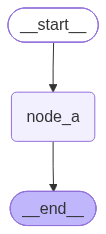

{'__interrupt__': [Interrupt(value='请输入您的姓名', id='d489b58fb91868aac66b192b4baa96a2')]}
请输入您的姓名
{'username': 'fyk'}


In [1]:
from typing import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver


#1. 声明状态
class OverAllState(TypedDict):
    username:str

#2. 声明节点
def node_a(state:OverAllState)->OverAllState:
    username = interrupt("请输入您的姓名")
    return {
        "username":username
    }

#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a",node_a)
builder.add_edge(START,"node_a")
builder.add_edge("node_a",END)

#4. 想要使用中断 => 必须配置检查点
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

config = {"configurable":{"thread_id":"123"}}
interrupt_res = graph.invoke({},config=config)
print(interrupt_res)

prompt = interrupt_res['__interrupt__'][0].value
print(prompt)
username = input(prompt)
# 5. 恢复图的中断执行
resume_res = graph.invoke(Command(resume=username),config=config)
print(resume_res)

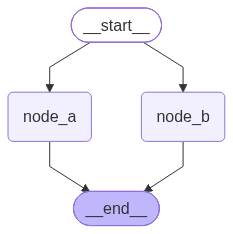

============================== -> interrupt_res <- ==============================
{'__interrupt__': [Interrupt(value='请输入您的姓名', id='72df4b84bb4dd02efa337940cf6976e8'), Interrupt(value='请输入您的年龄', id='9edeeaf83dfa1c4228facab17d1bf143')]}
============================== -> resumed_res <- ==============================
{'username': 'fyk', 'age': 23}


In [2]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

class OverAllState(TypedDict):
    username: str
    age: int

def node_a(state: OverAllState) -> OverAllState:
    username = interrupt("请输入您的姓名")
    return {
        "username": username
    }

def node_b(state: OverAllState) -> OverAllState:
    age = interrupt("请输入您的年龄")
    return {
        "age": age
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_edge(START, "node_a")
builder.add_edge(START, "node_b")
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "123"}}
interrupted_res = graph.invoke({}, config=config)
print('=' * 30, '-> interrupt_res <-', '=' * 30)
print(interrupted_res)

# 构建 中断ID -> 恢复指令 的映射
resume_map = {}
for i in interrupted_res['__interrupt__']:
    user_input = input(f"{i.value}: ")
    if "年龄" in i.value:
        resume_map[i.id] = int(user_input)
    else:
        resume_map[i.id] = user_input

resumed_res = graph.invoke(Command(resume=resume_map), config=config)
print('=' * 30, '-> resumed_res <-', '=' * 30)
print(resumed_res)

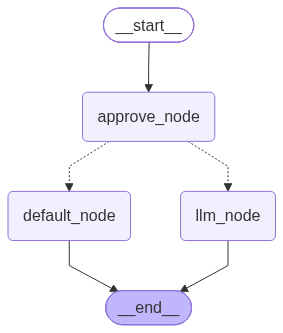

{'topic': '菊花', '__interrupt__': [Interrupt(value='是否同意调用模型?', id='e35bb97ca94f599d922df336ccc8a65c')]}
{'topic': '菊花', 'poem': '《咏菊》\n百花凋谢始登场，披甲金鳞战冷霜。\n宁可抱香枝上老，不随黄叶舞秋风。', 'is_approved': True}
{'topic': '牡丹花', '__interrupt__': [Interrupt(value='是否同意调用模型?', id='4d484d666e48d771a4cde2a7f499eead')]}
{'topic': '牡丹花', 'poem': '请求被拒绝', 'is_approved': False}


In [3]:
from time import sleep
from typing import TypedDict, Literal

from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph,START,END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from langchain_deepseek import ChatDeepSeek

from dotenv import load_dotenv
load_dotenv(override=True)

model =ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking":{
            "type":"disabled"
        }
    }
)

#1. 声明状态
class OverAllState(TypedDict):
    topic:str
    poem:str
    is_approved:bool

#2. 声明节点
def approve_node(state:OverAllState) -> Command[Literal["llm_node","default_node"]]:
    is_approved = interrupt("是否同意调用模型?")
    goto = "llm_node" if is_approved else "default_node"
    return Command(
        goto=goto,
        update={"is_approved":is_approved}
    )

def llm_node(state:OverAllState) -> OverAllState:
    topic = state["topic"]
    res = model.invoke([HumanMessage(content=f"帮我写一首关于{topic}主题的七言绝句,只写诗句,不需要赏析")]).content

    return {
        "poem":res
    }

def default_node(state:OverAllState) -> OverAllState:
    return {
        "poem":"请求被拒绝"
    }

#3. 构建图
builder = StateGraph(state_schema=OverAllState)

builder.add_node("approve_node",approve_node)
builder.add_node("llm_node",llm_node)
builder.add_node("default_node",default_node)
builder.add_edge(START,"approve_node")
builder.add_edge("llm_node",END)
builder.add_edge("default_node",END)

#4. 添加检查点后端
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

#5. 首次执行 -> 触发中断
config = {"configurable":{"thread_id":"234"}}
interrupt_res = graph.invoke({"topic":"菊花"},config=config)
print(interrupt_res)
#6. 人工审核
user_approved = input("是否同意调用模型?(y/n)").strip().lower() == 'y'
# 重新调用图
approved_res = graph.invoke(Command(resume=user_approved),config=config)
print(approved_res)

#7. 审核不通过
config1 = {"configurable":{"thread_id":"456"}}
interrupt_res = graph.invoke({"topic":"牡丹花"},config=config1)
print(interrupt_res)

user_approved = input("是否同意调用模型?(y/n)").strip().lower() == 'y'
# 重新调用图
approved_res = graph.invoke(Command(resume=user_approved),config=config1)
print(approved_res)

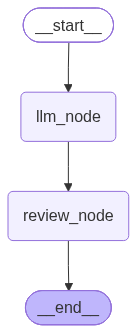

============================== -> interrupt_res <- ==============================
{'topic': '布偶猫', 'poem': '《咏布偶猫》\n蓝瞳雪魄步云轻，玉爪霓裳卧锦茵。\n解语悄伏膝上暖，一庭花影共春深。', '__interrupt__': [Interrupt(value={'instruction': '请审核并修改大模型生成的七言绝句', 'poem': '《咏布偶猫》\n蓝瞳雪魄步云轻，玉爪霓裳卧锦茵。\n解语悄伏膝上暖，一庭花影共春深。'}, id='ca2eabaf267de2ebcc8e6ec8e891709c')]}
原始诗句：
《咏布偶猫》
蓝瞳雪魄步云轻，玉爪霓裳卧锦茵。
解语悄伏膝上暖，一庭花影共春深。
============================== -> reviewed_res <- ==============================
{'topic': '布偶猫', 'poem': '《咏布偶猫》\n蓝瞳雪魄步云轻，玉爪霓裳卧锦茵。\n解语悄伏膝上暖，一庭花影共春深。', 'reviewed_poem': '《咏布偶猫》\n蓝瞳雪魄步云轻，玉爪霓裳卧锦茵。\n解语悄伏膝上暖，一庭花影共春深。'}


In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    reviewed_poem: str

def llm_node(state: OverAllState) -> OverAllState:
    topic = state['topic']

    res = model.invoke([HumanMessage(content=f"帮我写一首关于 {topic} 的七言绝句，只给出诗句，不要赏析")]).content
    return {
        "poem": res
    }

def review_node(state: OverAllState) -> OverAllState:
    reviewed_poem = interrupt({
        "instruction": "请审核并修改大模型生成的七言绝句",
        "poem": state['poem']
    })
    return {
        "reviewed_poem": reviewed_poem
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("llm_node", llm_node)
builder.add_node("review_node", review_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", "review_node")
builder.add_edge("review_node", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "review_test"}}
interrupted_res = graph.invoke({"topic": "布偶猫"}, config=config)
print('=' * 30, '-> interrupt_res <-', '=' * 30)
print(interrupted_res)

print("原始诗句：")
print(interrupted_res['__interrupt__'][0].value['poem'])
user_review = input("请审核并修改诗句（直接回车保留原诗）: ")
if not user_review.strip():
    user_review = interrupted_res['__interrupt__'][0].value['poem']
reviewed_res = graph.invoke(Command(resume=user_review), config=config)
print('=' * 30, '-> reviewed_res <-', '=' * 30)
print(reviewed_res)